# Olist 이커머스 EDA & RFM 분석 — 방법론 정리 및 코드

Kaggle 노트북 [Olist E-commerce EDA and RFM analysis (marta99)](https://www.kaggle.com/code/marta99/olist-e-commerce-eda-and-rfm-analysis)를 참고하여, **전체 흐름·방법론 번역**, **코드 구현**, **결론 요약**을 한 번에 정리한 노트북입니다.

---

## 1. RFM 분석이란 (방법론 번역·요약)

**RFM**은 **Recency(최근성), Frequency(빈도), Monetary(금액)** 세 가지 지표로 고객을 나누는 **정량적 고객 세분화** 방법이다.

| 지표 | 영문 | 의미 | 해석 |
|------|------|------|------|
| **R** | Recency | 마지막 구매로부터 경과 일수 | 숫자가 **작을수록** 좋음(최근 구매) → 점수는 **클수록** 좋게 부여(5=최근) |
| **F** | Frequency | 분석 기간 내 구매 횟수 | **클수록** 좋음 → 점수 1~5 (5=많이 구매) |
| **M** | Monetary | 분석 기간 내 총 결제 금액 | **클수록** 좋음 → 점수 1~5 (5=고액) |

**전체 흐름**  
1. **기준일(snapshot date)** 정하기 — 예: 데이터의 마지막 주문일 또는 분석일.  
2. **고객별 R, F, M 계산** — R = 기준일 − 마지막 주문일(일 단위), F = 주문 횟수, M = 총 결제액.  
3. **R/F/M 각각을 1~5점으로 구간화** — 보통 5분위(quantile) 또는 구간으로 나누어 5=최고, 1=최저.  
4. **RFM 점수 조합으로 세그먼트 부여** — 예: R=5,F=5,M=5 → "Champions", R=1,F=1,M=1 → "Lost".  
5. **세그먼트별 인사이트·마케팅 제안** 도출.

**세그먼트 이름(영문)과 의미(해석)**  
- **Champions** (R↑ F↑ M↑): 최고 가치 고객. 보상·VIP 프로그램.  
- **Loyal Customers**: 충성도 높음. 크로스셀·업셀.  
- **Potential Loyalists**: 최근·금액 괜찮음, 빈도만 늘리면 됨.  
- **New Customers**: 최근 첫 구매. 이탈 방지·재구매 유도.  
- **Promising**: 새로 들어온 고객, 아직 F·M 낮음.  
- **Need Attention**: 과거엔 좋았는데 R이 나빠짐. 재참여 캠페인.  
- **About to Sleep**: R이 평균 이하. 리텐션 캠페인.  
- **At Risk**: 과거 고객인데 오래 안 삼. win-back.  
- **Can't Lose Them**: M은 높았는데 오래 안 삼. 맞춤 복귀 제안.  
- **Hibernating**: 오래 전 구매, F·M 낮음. 재활성화 비용 대비 효과 검토.  
- **Lost**: R·F·M 모두 낮음. 재획득 비용이 크면 저우선순위.


---
## 2. 데이터 로드

**흐름**: data/ 존재 여부 확인 → 없으면 kagglehub에서 Olist 주문·결제·고객 데이터 로드 → delivered 주문만 사용.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "orders_delivered.csv").exists():
        DATA_DIR = _
        break

if not (DATA_DIR / "orders_delivered.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
    orders = orders[orders["order_status"] == "delivered"].copy()
    customers = pd.read_csv(_path / "olist_customers_dataset.csv")
    order_payments = pd.read_csv(_path / "olist_order_payments_dataset.csv")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")
    customers = pd.read_csv(DATA_DIR / "customers.csv")
    order_payments = pd.read_csv(DATA_DIR / "order_payments.csv")
    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")

# 주문별 결제액 (여러 결제 수단 합산)
order_value = order_payments.groupby("order_id")["payment_value"].sum().reset_index().rename(columns={"payment_value": "order_value"})
orders = orders.merge(order_value, on="order_id")
orders = orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")

print("orders(delivered):", orders.shape)
print("기간:", orders["order_purchase_timestamp"].min(), "~", orders["order_purchase_timestamp"].max())

orders(delivered): (96477, 10)
기간: 2016-10-03 09:44:50 ~ 2018-08-29 15:00:37


---
## 3. 기준일 설정 및 고객별 R, F, M 계산

**흐름**: 기준일 = 데이터 내 마지막 주문일 + 1일 → 고객별로 **Recency**(기준일 − 마지막 주문일, 일), **Frequency**(주문 횟수), **Monetary**(총 결제액) 집계.

In [2]:
# 기준일(snapshot date): 분석 시점 = 데이터의 마지막 주문일 + 1일
snapshot_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
snapshot_date = pd.Timestamp(snapshot_date.date())
print("기준일(snapshot date):", snapshot_date)

# 고객별 R, F, M
rfm = orders.groupby("customer_unique_id").agg(
    last_order=("order_purchase_timestamp", "max"),
    order_count=("order_id", "nunique"),
    total_value=("order_value", "sum"),
).reset_index()

rfm["Recency"] = (snapshot_date - rfm["last_order"]).dt.days
rfm["Frequency"] = rfm["order_count"]
rfm["Monetary"] = rfm["total_value"]

rfm = rfm[["customer_unique_id", "Recency", "Frequency", "Monetary"]].copy()
print("\nRFM 요약 통계:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())
print("\n샘플:")
print(rfm.head(10))

기준일(snapshot date): 2018-08-30 00:00:00

RFM 요약 통계:
        Recency  Frequency  Monetary
count 93357.000  93357.000 93357.000
mean    237.474      1.033   165.199
std     152.588      0.209   226.315
min       0.000      1.000     9.590
25%     114.000      1.000    63.060
50%     218.000      1.000   107.780
75%     346.000      1.000   182.560
max     695.000     15.000 13664.080

샘플:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1   141.900
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1    27.190
2  0000f46a3911fa3c0805444483337064      537          1    86.220
3  0000f6ccb0745a6a4b88665a16c9f078      321          1    43.620
4  0004aac84e0df4da2b147fca70cf8255      288          1   196.890
5  0004bd2a26a76fe21f786e4fbd80607f      146          1   166.980
6  00050ab1314c0e55a6ca13cf7181fecf      131          1    35.380
7  00053a61a98854899e70ed204dd4bafe      182          1   419.180
8  0005e1862207b

---
## 4. R, F, M 점수화 (1~5)

**방법**: 5분위(quantile)로 나누어 1~5점 부여.  
- **R**: Recency가 **작을수록** 좋음 → q가 작을수록 높은 점수. 따라서 `pd.qcut(Recency, 5, labels=[5,4,3,2,1])` 사용.  
- **F, M**: **클수록** 좋음 → `pd.qcut(..., labels=[1,2,3,4,5])` 또는 동일 구간 수로 5점 만점.

In [3]:
# R: 작을수록 좋음 → Recency 작을수록 5점 (rank로 동점 처리 후 5분위, 역순 라벨)
rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), q=5, labels=[5, 4, 3, 2, 1], duplicates="drop").astype(int)
# F, M: 클수록 좋음 → 5등급=5점 (동점 시 rank로 구간 균등 분할)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(int)

# RFM 문자열 (555 형태)
rfm["RFM_group"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

print("점수 분포:")
print(rfm[["R_score", "F_score", "M_score"]].describe())
print("\nRFM_group 샘플:")
print(rfm["RFM_group"].value_counts().head(15))

점수 분포:
        R_score   F_score   M_score
count 93357.000 93357.000 93357.000
mean      3.000     3.000     3.000
std       1.414     1.414     1.414
min       1.000     1.000     1.000
25%       2.000     2.000     2.000
50%       3.000     3.000     3.000
75%       4.000     4.000     4.000
max       5.000     5.000     5.000

RFM_group 샘플:
RFM_group
555    997
455    955
255    910
355    882
222    865
155    851
242    847
424    839
531    835
131    830
344    818
331    816
454    811
121    808
112    806
Name: count, dtype: int64


---
## 5. RFM 세그먼트 레이블 부여

**흐름**: R_score, F_score, M_score 조합에 따라 **Champions, Loyal, At Risk, Lost** 등 세그먼트 이름을 매핑.

In [4]:
def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 4 and f >= 2 and m >= 2:
        return "Loyal Customers"
    if r >= 4 and f <= 2 and m <= 2:
        return "Promising"
    if r >= 4 and f <= 2:
        return "New Customers"
    if r >= 3 and f >= 3 and m >= 3:
        return "Potential Loyalists"
    if r >= 3 and f <= 2 and m >= 3:
        return "Need Attention"
    if r >= 2 and r <= 3 and f <= 2:
        return "About to Sleep"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    if r <= 2 and f <= 2 and m >= 4:
        return "Can't Lose Them"
    if r <= 2 and f >= 2:
        return "Hibernating"
    return "Lost"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

print("세그먼트별 고객 수:")
print(rfm["Segment"].value_counts().sort_index())
print("\n세그먼트별 R/F/M 평균:")
print(rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(1))

세그먼트별 고객 수:
Segment
About to Sleep         10458
At Risk                13227
Can't Lose Them         2849
Champions               6464
Hibernating            11443
Lost                   11268
Loyal Customers        17565
Need Attention          4346
New Customers           4545
Potential Loyalists     6799
Promising               4393
Name: count, dtype: int64

세그먼트별 R/F/M 평균:
                     Recency  Frequency  Monetary
Segment                                          
About to Sleep       287.700      1.000   133.400
At Risk              392.500      1.100   243.700
Can't Lose Them      473.300      1.000   305.600
Champions             90.300      1.200   312.300
Hibernating          410.900      1.000    59.100
Lost                 221.800      1.000    52.700
Loyal Customers       89.800      1.000   162.400
Need Attention       220.000      1.000   223.100
New Customers         90.200      1.000   234.100
Potential Loyalists  219.600      1.100   226.400
Promising         

---
## 6. 시각화

**흐름**: 세그먼트별 고객 수 막대 차트, 세그먼트별 평균 Monetary·Frequency, R×F 히트맵(또는 산점도) 등.

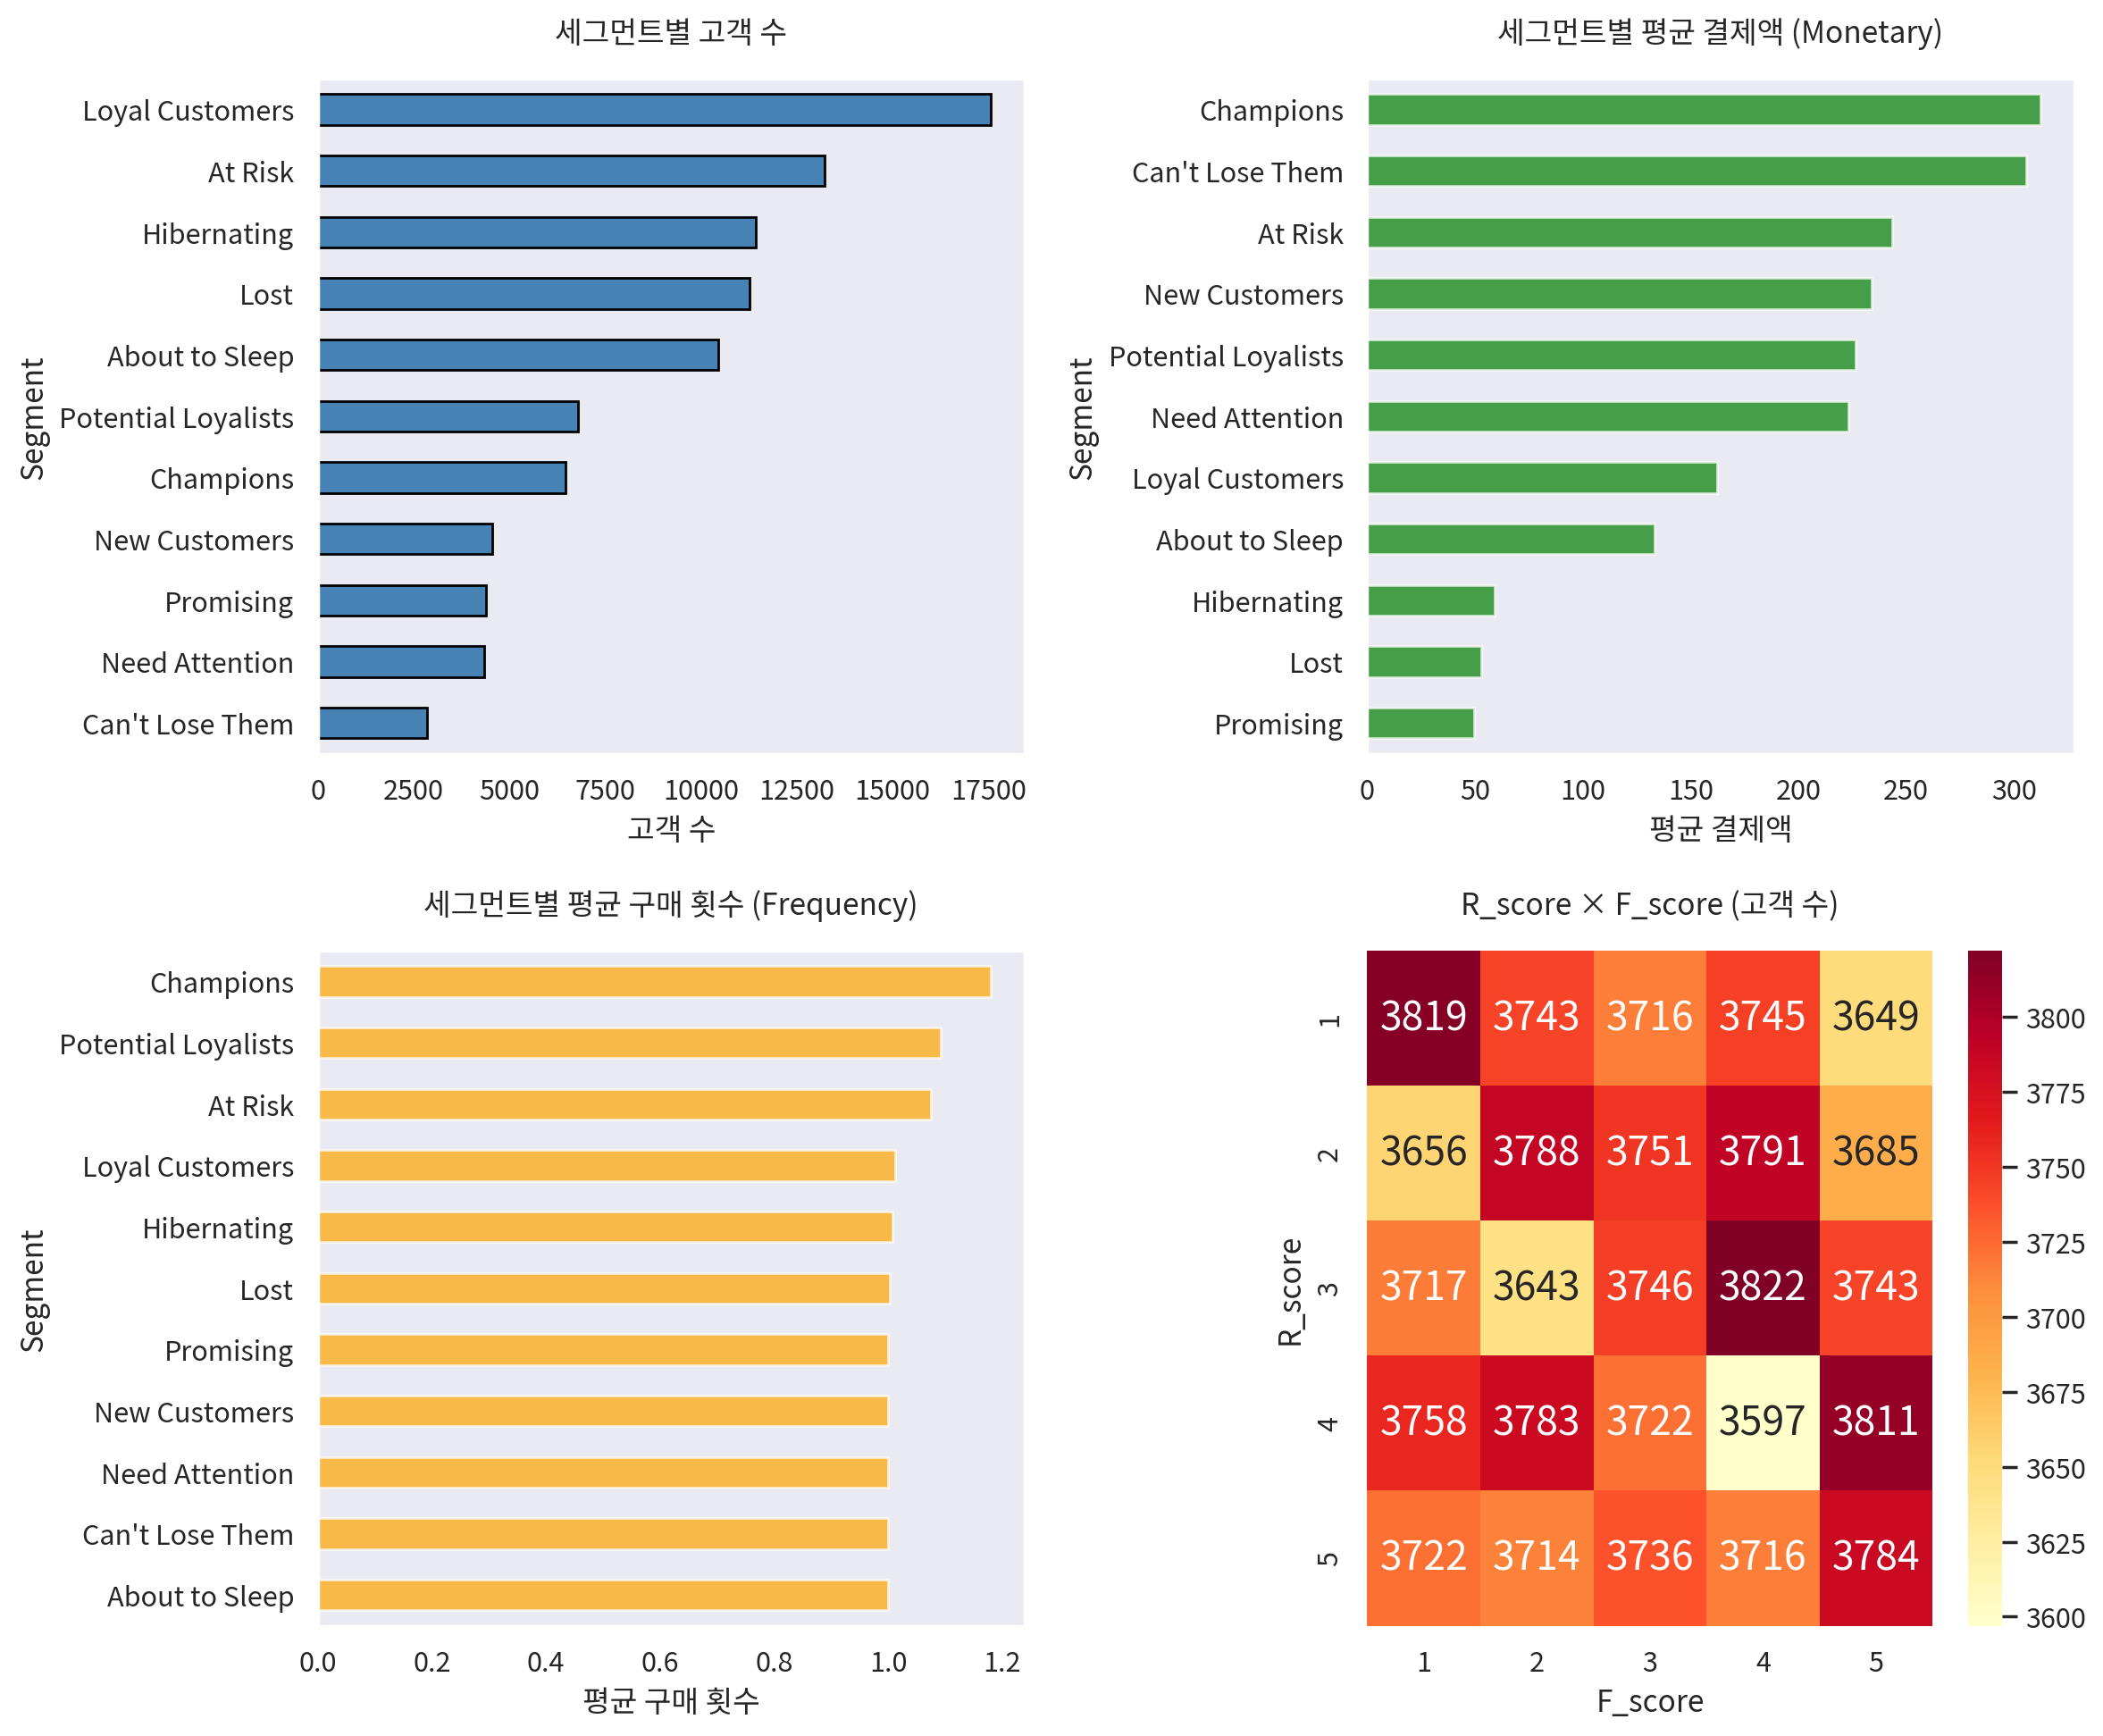

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (1) 세그먼트별 고객 수
seg_counts = rfm["Segment"].value_counts().sort_values(ascending=True)
seg_counts.plot(kind="barh", ax=axes[0, 0], color="steelblue", edgecolor="black")
axes[0, 0].set_title("세그먼트별 고객 수")
axes[0, 0].set_xlabel("고객 수")

# (2) 세그먼트별 평균 Monetary
rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=True).plot(kind="barh", ax=axes[0, 1], color="green", alpha=0.7)
axes[0, 1].set_title("세그먼트별 평균 결제액 (Monetary)")
axes[0, 1].set_xlabel("평균 결제액")

# (3) 세그먼트별 평균 Frequency
rfm.groupby("Segment")["Frequency"].mean().sort_values(ascending=True).plot(kind="barh", ax=axes[1, 0], color="orange", alpha=0.7)
axes[1, 0].set_title("세그먼트별 평균 구매 횟수 (Frequency)")
axes[1, 0].set_xlabel("평균 구매 횟수")

# (4) R_score × F_score 교차표 (고객 수)
rf_cross = pd.crosstab(rfm["R_score"], rfm["F_score"])
sns.heatmap(rf_cross, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("R_score × F_score (고객 수)")
axes[1, 1].set_xlabel("F_score")
axes[1, 1].set_ylabel("R_score")

plt.tight_layout()
plt.show()

---
## 7. 세그먼트별 요약 테이블 (매출 기여도)

**흐름**: 세그먼트별 고객 수, 총 매출, 평균 R/F/M → 매출 기여 비율 계산.

In [6]:
summary = rfm.groupby("Segment").agg(
    고객수=("customer_unique_id", "count"),
    총매출=("Monetary", "sum"),
    평균_Recency=("Recency", "mean"),
    평균_Frequency=("Frequency", "mean"),
    평균_Monetary=("Monetary", "mean"),
).round(1)
total_revenue = summary["총매출"].sum()
summary["매출_기여율"] = (summary["총매출"] / total_revenue * 100).round(1)
summary = summary.sort_values("총매출", ascending=False)
print("세그먼트별 요약 (매출 기여율 포함):")
print(summary)

세그먼트별 요약 (매출 기여율 포함):
                       고객수         총매출  평균_Recency  평균_Frequency  평균_Monetary  \
Segment                                                                         
At Risk              13227 3223292.000     392.500         1.100      243.700   
Loyal Customers      17565 2853254.900      89.800         1.000      162.400   
Champions             6464 2018545.000      90.300         1.200      312.300   
Potential Loyalists   6799 1539355.400     219.600         1.100      226.400   
About to Sleep       10458 1395593.000     287.700         1.000      133.400   
New Customers         4545 1064178.600      90.200         1.000      234.100   
Need Attention        4346  969667.800     220.000         1.000      223.100   
Can't Lose Them       2849  870562.800     473.300         1.000      305.600   
Hibernating          11443  676202.200     410.900         1.000       59.100   
Lost                 11268  593846.700     221.800         1.000       52.700   
Promis

---
## 8. 결론 정리 및 요약

### 8.1 RFM 방법론 요약

| 단계 | 내용 |
|------|------|
| 1 | 기준일 설정 후 고객별 Recency(마지막 구매 경과일), Frequency(구매 횟수), Monetary(총 결제액) 계산 |
| 2 | R/F/M 각각 5분위로 1~5점 부여 (R은 작을수록 좋으므로 5=최근) |
| 3 | R,F,M 점수 조합으로 Champions, Loyal, At Risk, Lost 등 11개 세그먼트 부여 |
| 4 | 세그먼트별 고객 수·매출 기여도·평균 지표로 차트·테이블 시각화 |

### 8.2 세그먼트별 마케팅 제안 (해석)

| 세그먼트 | 특성 | 제안 |
|----------|------|------|
| **Champions** | 최근·자주·고액 | VIP 보상, 추천 프로그램, 크로스셀 |
| **Loyal Customers** | 최근·충성 | 로열티 강화, 업셀 |
| **Potential Loyalists** | 괜찮은 R·F·M | 구매 빈도 유도 (쿠폰·알림) |
| **New Customers** | 최근 첫 구매 | 웰컴 시퀀스, 재구매 유도 |
| **Promising** | 최근, F·M 낮음 | 상품 추천으로 객단가·빈도 상승 |
| **Need Attention** | 과거 고객, R 나쁨 | 리텐션 캠페인, 할인/이벤트 |
| **About to Sleep** | R 평균 이하 | 이메일·푸시로 재방문 유도 |
| **At Risk** | 과거 자주 샀는데 오래 안 삼 | Win-back 캠페인, 맞춤 오퍼 |
| **Can't Lose Them** | 고액이었는데 오래 안 삼 | 1:1 복귀 제안 |
| **Hibernating** | 오래됨, F·M 낮음 | 재활성화 비용 대비 효과 검토 |
| **Lost** | R·F·M 모두 낮음 | 재획득 비용 높으면 저우선순위 |

### 8.3 인사이트 요약

- **Champions·Loyal** 등 상위 세그먼트가 **매출 기여율**이 크게 나오는 경우가 많다 (파레토 법칙).  
- **At Risk, Can't Lose Them**은 과거 가치가 높았으므로 **우선 win-back** 대상.  
- **New Customers, Promising**은 이탈 방지·재구매 유도로 **성장 세그먼트**로 키울 수 있다.  
- R×F 히트맵에서 (5,5) 근처가 Champions, (1,1) 근처가 Lost에 해당하는지 확인하면 점수 체계가 잘 적용되었는지 검증할 수 있다.